In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn

In [ ]:
#device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)

In [ ]:
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("fmnist_small.csv")

Saving fmnist_small.csv to fmnist_small.csv


In [ ]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Basic Graph

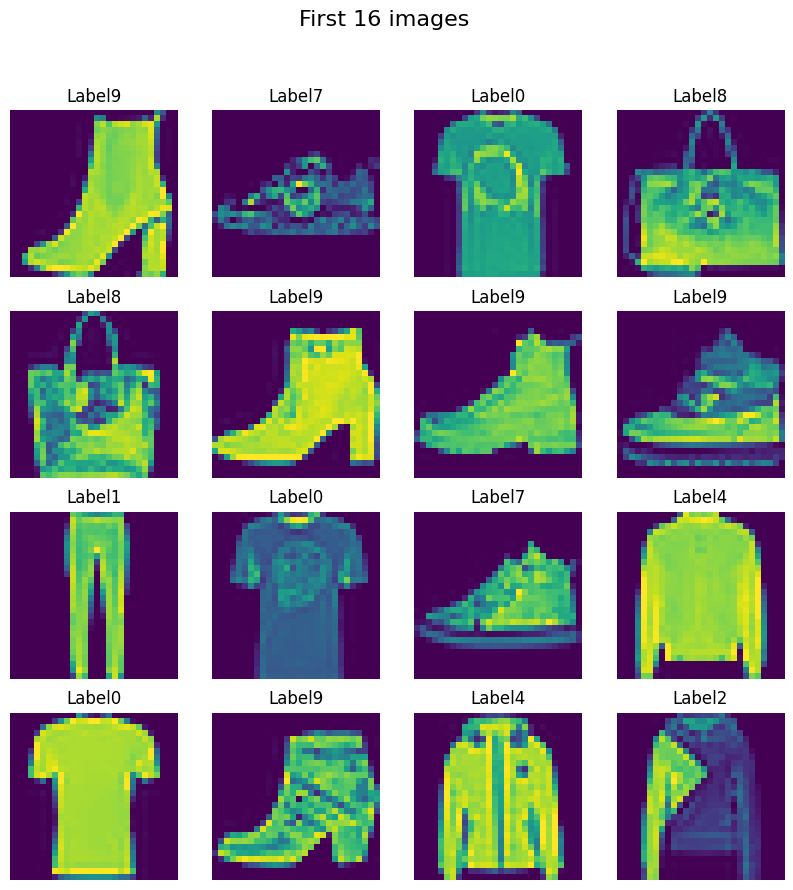

In [ ]:
fig, axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=16)

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')              ## Image Axis Off
  ax.set_title(f"Label{df.iloc[i,0]}")    ## Image title set as Label i= image 0 =label index of the image

In [ ]:
df['label'].nunique()       ## Output layer node = 10 so we use softmax in o/p layer and ReLU in Hidden layer

10

## hidden layer1= 128
## hiddden layer2=64
## o/p layer=10

# Train Test Splitting

In [ ]:
X=df.iloc[:,1:].values  ## Takes all colum accept 1 st column or index 0 column
y=df.iloc[:,0].values   ## Takes only 1 column which index=0

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
## Scalling

X_train=X_train/255.0
X_test=X_test/255.0

## WorkFlow

## Dataloader -----> Training PipeLine(Loop) -------> Model evalution

# CUSTOM DATASET CLASS

In [ ]:
class CustomDataSet(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)    ## Pytoch works well when features datatype = **float32**
    self.labels=torch.tensor(labels,dtype=torch.long)        ## Pytoch works well when label datatype is **longint**

  def __len__(self):
    return self.features.shape[0]
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [ ]:
train_dataset=CustomDataSet(X_train,y_train)
test_dataset=CustomDataSet(X_test,y_test)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)    ## Never shuffle in test dataset

#For GPU
#train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
#test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True

# Define NN

In [ ]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),
    )

  def forward(self,X):
    return self.model(X)

In [ ]:
epochs=10
lr=0.1

In [ ]:
model=MyNN(X_train.shape[1])


In [ ]:
# model= model.to(device)

In [ ]:
## Categorical Cross Entropy Function
criterion= nn.CrossEntropyLoss()

In [ ]:
optimizer= torch.optim.SGD(model.parameters(),lr=lr)

# Training Loop

In [ ]:
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:

    #For GPU

    #batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    #Forward pass
    output=model(batch_features)

    # Calculate loss
    loss=criterion(output,batch_labels)
    # Backpass
    optimizer.zero_grad()
    loss.backward()
    # Parameter update
    optimizer.step()
    #print(loss.item)                 all losses wll bw printed
    total_epoch_loss +=loss.item()

avg_loss=total_epoch_loss/len(train_loader)
print(avg_loss)

0.40518137445052466


# Model Evalution

In [ ]:
model.eval()
total=0
correct=0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:

    #For GPU

    #batch_features, batch_labels=batch_features.to(device),batch_labels.to(device)


    output=model(batch_features)
    #print(f"outputs{output}")
    _,predicted=torch.max(output,dim=1)
    #print(f"predicted{predicted}")

    total+=batch_labels.size(0)
    correct+=(predicted==batch_labels).sum().item()

print(f"total number :{total}")
print(f"Correct :{correct}")
print(f"Accuracy : {correct/total}")
#

total number :1200
Correct :989
Accuracy : 0.8241666666666667
